Домашнее задание

ДЗ №4 «Портфель - средство снижения риска»

Цель:

Студенты учатся формировать портфельную стратегию для снижения риска и повышения качества модели.
Результат - сформирована модель на базе портфельной стратегии.


Описание/Пошаговая инструкция выполнения домашнего задания:

 - Создать модель (торговую стратегию) на основе классического портфеля.
 - Протестировать различные уровни риска как гиперпараметра модели для достижения вашего конкретного уровня доходности/риска.
 - Провести тестирование разработанной стратегии на валидационном датасете.
 - Сформировать дашборд, показывающий эффективность различных портфелей по критерию риск/доходность.

Загрузка библиотек

In [ ]:
!/Users/lmv/anaconda3/envs/mlfinance/bin/pip install PyPortfolioOpt
!pip install pyportfolioopt
!/Users/lmv/anaconda3/envs/mlfinance/bin/pip install tqdm
!pip install tslearn
!pip install curl_cffi

/bin/bash: line 1: /Users/lmv/anaconda3/envs/mlfinance/bin/pip: No such file or directory
/bin/bash: line 1: /Users/lmv/anaconda3/envs/mlfinance/bin/pip: No such file or directory


In [ ]:
import yfinance as yf
import pandas as pd
from scipy import stats

from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns, get_latest_prices, DiscreteAllocation
from pypfopt.cla import CLA
import pypfopt.plotting as pplt

from collections import OrderedDict
from matplotlib.ticker import FuncFormatter

from sqlalchemy import create_engine
from tqdm import tqdm

import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import IPython
import IPython.display
import matplotlib as mpl
from curl_cffi import requests

mpl.rcParams['figure.figsize'] = (12, 6)
mpl.rcParams['axes.grid'] = False

Загрузка данных

https://vc.ru/money/238241-vechnye-portfeli-sravnivaem-podhody-dalio-i-brauna
https://sky.pro/wiki/money/konservativnyj-investicionnyj-portfel-struktura-aktivy-riski/

"Всепогодный портфель" Далио:

• 40%: VGLT (ETF на казначейские облигации США 20+ лет);

• 30%: VTI Vanguard Total Stock Market (ETF на акции США);

• 15%: IEF iShares (ETF на казначейские облигации США 7–10 лет);

• 7,5%: GLD SPDR Gold Shares (ETF, акции которого на 100% обеспечены физическим золотом);

• 7,5%: DBC PowerShares DB Commodity Index Tracking Fund (фонд, реплицирующий товарный индекс, в который входят нефть, мазут, бензин, природный газ, золото, серебро, алюминий, цинк, медь, кукуруза, пшеница, соя и сахар).

Мосбиржа:
На отечественном рынке (Мосбирже)можно собрать несколько модифицированную версию, например:

• 40%: FXMM - ETF на долгосрочные гособлигации США, или ОФЗ Минфина России для портфеля в рублях;

• 30%: FXWO - ETF на акции крупнейших международных компаний;

• 15%: 7-10-летние ОФЗ или VTBB - БПИФ корпоративных облигаций, котирующихся на Московской Бирже;

• 7,5%: ETF на золото FXGD или БПИФ от ВТБ с физическим золотом в портфеле, тикер VTBG;

• 7,5%: к сожалению, отсутствует какой-либо единый инструмент.

Произвольно сгенерированные инструменты

In [ ]:
import yfinance as yf

tickers_list = [
    "AAPL", "MSFT", "GOOG", "AMZN", "NVDA", "TSLA", "META", "BRK-B", "JNJ", "V",
    "UNH", "LLY", "XOM", "JPM", "PG", "HD", "MA", "CVX", "MRK", "ABBV",
    "KO", "BAC", "PEP", "COST", "ADBE", "CRM", "AVGO", "SHEL", "ACN", "TMO",
    "NSRGY", "CSCO", "PFE", "CMCSA", "WMT", "ORCL", "TMUS", "WFC", "DHR", "VZ",
    "DIS", "INTC", "QCOM", "PM", "IBM", "AMAT", "GE", "MDLZ", "HON", "SBUX",
    "NFLX", "PYPL", "AMD", "INTU", "CHTR", "MU", "GILD", "LMT", "BA", "CAT",
    "CVS", "DE", "GS", "LOW", "MCD", "MMM", "NKE", "PCLN", "SIRI", "TGT",
    "TXN", "UPS", "USB", "WBA", "WM", "WYNN", "ZTS", "BABA", "BHP", "BP",
    "C", "DWDP", "FBHS", "FOX", "GPN", "HCA", "HSY", "KHC", "LULU", "MELI",
    "MRNA", "NOW", "PANW", "PLD", "PTON", "RIVN", "ROKU", "SNAP", "SQ"
]

print(tickers_list)

['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA', 'TSLA', 'META', 'BRK-B', 'JNJ', 'V', 'UNH', 'LLY', 'XOM', 'JPM', 'PG', 'HD', 'MA', 'CVX', 'MRK', 'ABBV', 'KO', 'BAC', 'PEP', 'COST', 'ADBE', 'CRM', 'AVGO', 'SHEL', 'ACN', 'TMO', 'NSRGY', 'CSCO', 'PFE', 'CMCSA', 'WMT', 'ORCL', 'TMUS', 'WFC', 'DHR', 'VZ', 'DIS', 'INTC', 'QCOM', 'PM', 'IBM', 'AMAT', 'GE', 'MDLZ', 'HON', 'SBUX', 'NFLX', 'PYPL', 'AMD', 'INTU', 'CHTR', 'MU', 'GILD', 'LMT', 'BA', 'CAT', 'CVS', 'DE', 'GS', 'LOW', 'MCD', 'MMM', 'NKE', 'PCLN', 'SIRI', 'TGT', 'TXN', 'UPS', 'USB', 'WBA', 'WM', 'WYNN', 'ZTS', 'BABA', 'BHP', 'BP', 'C', 'DWDP', 'FBHS', 'FOX', 'GPN', 'HCA', 'HSY', 'KHC', 'LULU', 'MELI', 'MRNA', 'NOW', 'PANW', 'PLD', 'PTON', 'RIVN', 'ROKU', 'SNAP', 'SQ']


In [ ]:
from pandas.core.arrays.datetimes import DatetimeArray

# Голубые фишки Мосбиржа
'''
SBER - Сбербанк
LKOH - Лукойл
GAZP - Газпром
GMKN - Норникель
NVTK - НОВАТЭК
ROSN - Роснефть
YNDX - Яндекс
MGNT - Магнит
PLZL - Полюс
TATN - Татнефть
SNGS - Сургутнефтегаз
CHMF - Северсталь
NLMK - НЛМК
ALRS - Алроса
TCSG - ТКС Холдинг (ранее Тинькофф)
MOEX - Московская Биржа (также является фишкой)
Нефть и Газ (не гиганты): НОВАТЭК (NVTK), Татнефть (TATN), Башнефть (BANE/BNEF).
Металлургические/Горнодобывающие: Мечел (MTLR), ММК (MAGN), Сегежа (SGZH), Полиметалл (POLY/POLY), Алроса (ALRS), Норникель (GMKN - иногда относят к фишкам, но не к крупнейшим).
Энергетика/Уголь: Интер РАО (IRAO - часто в фишках), РусГидро (HYDR), Кузбасразрезуголь (KUZB).
Химическая/Удобрения: ФосАгро (AGRO), Уралкалий (URKA).
'''

start_date='2022-01-01'
end_date ='2025-10-01'



In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
random_state = 42
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

Функция ребалансировки портфеля

In [ ]:
#https://habr.com/ru/articles/561980/
#https://smart-lab.ru/blog/558494.php

import pandas as pd
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices

# 1. Simulate some historical price data
# In a real scenario, you would fetch this from a financial data provider
##dates = pd.date_range(start='2020-01-01', periods=100, freq='D')
##tickers = ['AAPL', 'GOOG', 'MSFT']
##data = {
##    'AAPL': [150 + i * 0.5 + (i % 10) * 2 for i in range(100)],
##    'GOOG': [2000 + i * 1.2 + (i % 7) * 5 for i in range(100)],
##    'MSFT': [250 + i * 0.8 + (i % 5) * 3 for i in range(100)],
##}
##prices = pd.DataFrame(data, index=dates)

# Define rebalancing frequency (e.g., monthly)
##rebalance_frequency = 'M'

# Initial portfolio value and cash
##initial_portfolio_value = 100000


def rebalancingPortflolio(rebalancingData, reblancingTickers, rebalance_frequency = 'M', initial_portfolio_value = 100000, eff_weights = True, risk_target = None):

    cash = initial_portfolio_value
    tickers = reblancingTickers.copy()
    holdings = {ticker: 0 for ticker in tickers} # Initial holdings in shares
    rebalance = {ticker: 0 for ticker in tickers}
    rebalanceSignals = pd.DataFrame([rebalance]).iloc[0:0]
    prices = rebalancingData.copy()

    # Loop through rebalancing periods
    for start_date in prices.resample(rebalance_frequency).first().index:
        end_date = prices.resample(rebalance_frequency).last().index[
            prices.resample(rebalance_frequency).last().index > start_date
        ][0]

        # Get prices for the current rebalancing period
        current_prices = prices.loc[start_date:end_date]

        if len(current_prices) < 2: # Need at least two data points for returns
            continue

        # Calculate expected returns and covariance matrix
        mu = mean_historical_return(current_prices)
        cs = risk_models.CovarianceShrinkage(current_prices)
        S = cs.ledoit_wolf()

        # Optimize portfolio (e.g., maximize Sharpe ratio)
        #ef = EfficientFrontier(mu, S, weight_bounds=(0,1))
        #raw_weights = ef.max_sharpe()
        #cleaned_weights = ef.clean_weights()

        # Optimize portfolio (e.g., min Volatile ratio)
        ef = EfficientFrontier(mu, S, weight_bounds=(0,1))
        if eff_weights :
           raw_weights=ef.min_volatility()
        elif eff_weights == False :
           raw_weights=ef.max_sharpe()

        if risk_target is not None :
           raw_weights=ef.efficient_risk(risk_target, False)

        cleaned_weights=ef.clean_weights()

        # Get latest prices for discrete allocation
        latest_prices = get_latest_prices(current_prices)

        # Calculate current portfolio value based on current holdings and latest prices
        current_portfolio_value = sum(holdings[ticker] * latest_prices[ticker] for ticker in tickers) + cash

        # Perform discrete allocation based on new weights and current portfolio value
        da = DiscreteAllocation(cleaned_weights, latest_prices, total_portfolio_value=current_portfolio_value)
        allocations, leftover_cash = da.lp_portfolio()

        # Update holdings and cash
        for ticker, shares in allocations.items():
            # Calculate the change in shares
            shares_to_buy_sell = shares - holdings[ticker]

            if shares_to_buy_sell > 0: # Buying
                cost = shares_to_buy_sell * latest_prices[ticker]
                if cash >= cost:
                    holdings[ticker] += shares_to_buy_sell
                    rebalance[ticker] = 1
                    cash -= cost
                else:
                    # Handle insufficient cash (e.g., buy fewer shares)
                    pass
            elif shares_to_buy_sell < 0: # Selling
                revenue = abs(shares_to_buy_sell) * latest_prices[ticker]
                holdings[ticker] += shares_to_buy_sell # Reduce shares
                rebalance[ticker] = -1
                cash += revenue

        cash += leftover_cash # Add any leftover cash from the optimization
        rebalance['Date'] = end_date
        rebalanceSignals = pd.concat([rebalanceSignals, pd.DataFrame([rebalance])], axis = 0)

        ExpectedAnnualRetur, AnnualVolatility, SharpeRatio = ef.portfolio_performance(verbose=False)

        #print(f"Rebalancing on {end_date.strftime('%Y-%m-%d')}:")
        #print(f"  Optimal weights: {cleaned_weights}")
        #print(f"  Holdings: {holdings}")
        #print(f"  Remaining cash: {cash:.2f}")
        #print(f"  Total portfolio value: {sum(holdings[ticker] * latest_prices[ticker] for ticker in tickers) + cash:.2f}\n")

        if prices.resample(rebalance_frequency).last().index[-1] == end_date :
          break

    rebalancingMetrics = pd.DataFrame({
        "Rebalancing on" : [end_date.strftime('%Y-%m-%d')],
        "ExpectedAnnualRetur": [ExpectedAnnualRetur],
        "AnnualVolatility": [AnnualVolatility],
        "SharpeRatio": [SharpeRatio],
        "Optimal weights": [cleaned_weights],
        "Holdings": [holdings],
        "Remaining cash": [cash],
        "Total portfolio value": [(sum(holdings[ticker] * latest_prices[ticker] for ticker in tickers) + cash)]
    })

    # Format output
    rebalancingMetrics['Rebalancing on'] = rebalancingMetrics['Rebalancing on'].map(lambda x: f"{x}")
    rebalancingMetrics['ExpectedAnnualRetur'] = rebalancingMetrics['ExpectedAnnualRetur'].map(lambda x: f"{x*100:.2f}%")
    rebalancingMetrics['AnnualVolatility'] = rebalancingMetrics['AnnualVolatility'].map(lambda x: f"{x*100:.2f}%")
    rebalancingMetrics['SharpeRatio'] = rebalancingMetrics['SharpeRatio'].map(lambda x: f"{x:.2f}")
    rebalancingMetrics['Remaining cash'] = rebalancingMetrics['Remaining cash'].map(lambda x: f"{x:.2f}")
    rebalancingMetrics['Total portfolio value'] = rebalancingMetrics['Total portfolio value'].map(lambda x: f"{x:.2f}")

    return rebalanceSignals, rebalancingMetrics

Вычисление количества кластеров Elbow method

[*********************100%***********************]  94 of 94 completed


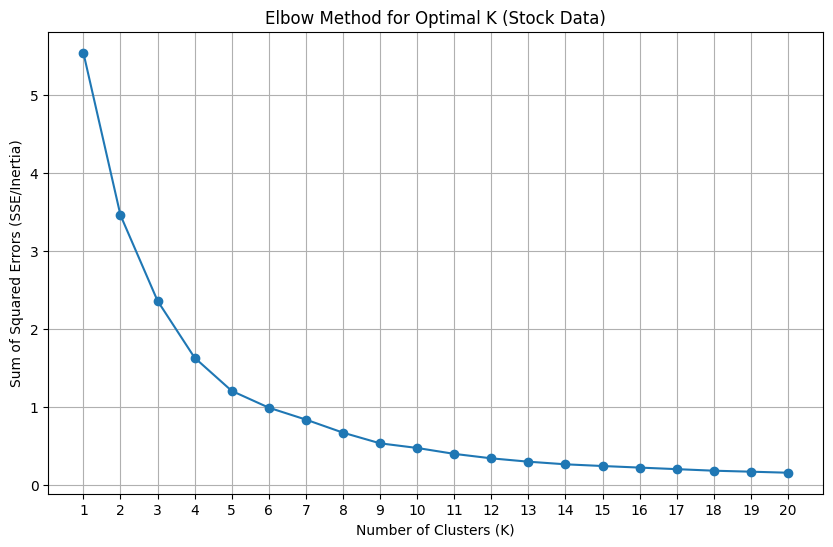

In [ ]:
#https://habr.com/ru/companies/skillfactory/articles/877684/
#https://sky.pro/wiki/python/klasterizaciya-v-mashinnom-obuchenii/

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

tickers_cls = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA', 'TSLA', 'META', 'BRK-B', 'JNJ', 'V', 'UNH', 'LLY', 'XOM', 'JPM', 'PG', 'HD'
, 'MA', 'CVX', 'MRK', 'ABBV', 'KO', 'BAC', 'PEP', 'COST', 'ADBE', 'CRM', 'AVGO', 'SHEL', 'ACN', 'TMO', 'NSRGY', 'CSCO', 'PFE'
, 'CMCSA', 'WMT', 'ORCL', 'TMUS', 'WFC', 'DHR', 'VZ', 'DIS', 'INTC', 'QCOM', 'PM', 'IBM', 'AMAT', 'GE', 'MDLZ'
, 'HON', 'SBUX', 'NFLX', 'PYPL', 'AMD', 'INTU', 'CHTR', 'MU', 'GILD', 'LMT', 'BA', 'CAT', 'CVS', 'DE', 'GS', 'LOW', 'MCD', 'MMM'
, 'NKE', 'SIRI', 'TGT', 'TXN', 'UPS', 'USB', 'WM', 'WYNN', 'ZTS', 'BABA', 'BHP', 'BP', 'C', 'FOX'
, 'GPN', 'HCA', 'HSY', 'KHC', 'LULU'
, 'MELI', 'MRNA', 'NOW', 'PANW', 'PLD', 'PTON', 'RIVN', 'ROKU', 'SNAP']
start_date_cls = '2024-01-01'
end_date_cls = '2025-01-01'

# Download data and pivot it
data_cls = yf.download(tickers_cls, start=start_date_cls, end=end_date_cls, auto_adjust=True)['Close']
data_cls = data_cls.dropna() # Drop any rows with missing values

# 2. Prepare the data: Calculate returns and volatility
# Daily returns
returns_cls = data_cls.pct_change().dropna()

# Annualized volatility (standard deviation * sqrt(252 trading days)) and mean annual return
# We use the mean of daily returns as an estimate of the expected daily return and annualize it
moments = pd.DataFrame()
moments['Returns'] = returns_cls.mean() * 252
moments['Volatility'] = returns_cls.std() * np.sqrt(252)

# Scale the data for clustering
scaler_cls = MinMaxScaler()
scaled_moments = scaler_cls.fit_transform(moments)

# 3. Apply the Elbow Method to find the optimal 'k'
sse = [] # Sum of Squared Errors (Inertia)
k_range = range(1, 21)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_moments)
    sse.append(kmeans.inertia_)

# 4. Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal K (Stock Data)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE/Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()


Кластеризация

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df_cluster = scaler.fit_transform(data_cls)
df_cluster = pd.DataFrame(df_cluster, columns = data_cls.columns)
clusters = 8
assetsCluster = KMeans(algorithm='elkan',  max_iter=800, n_clusters=clusters)
print('Clustering of assets completed!')
assetsCluster.fit(df_cluster[-180:].T)
centroids = assetsCluster.cluster_centers_
labels = assetsCluster.labels_
listcluster = pd.DataFrame(data=None, columns=['ncluster'], index=None)
listsCluster = pd.DataFrame(data=None, columns=['ncluster'], index=None)
print('Stocks in each of the clusters:\n',)
assets = np.array(df_cluster.columns)
for i in range(clusters):
    print('Cluster', i+1)
    clt  = np.where(labels == i)
    assetsCluster = assets[clt]
    listcluster = pd.concat([listcluster, pd.DataFrame(data = pd.DataFrame({'tickers': [np.array2string(assetsCluster, separator=',', precision=2)]}), columns=['tickers'])], axis = 0)
    listcluster['ncluster'].iloc[-1] = i+1
    print(assetsCluster)



Clustering of assets completed!
Stocks in each of the clusters:

Cluster 1
['AAPL' 'ADBE' 'CHTR' 'COST' 'GOOG' 'MSFT' 'NVDA' 'PG' 'PLD' 'RIVN' 'TXN']
Cluster 2
['AMZN' 'C' 'CRM' 'CSCO' 'DE' 'HON' 'NFLX' 'NOW' 'PTON' 'TSLA' 'V' 'WFC']
Cluster 3
['AMD' 'BA' 'BHP' 'BP' 'CVS' 'HSY' 'INTC' 'KHC' 'MDLZ' 'NKE' 'SIRI' 'TGT'
 'UPS' 'WYNN']
Cluster 4
['AMAT' 'MRK' 'MRNA' 'MU' 'NSRGY' 'QCOM' 'SHEL' 'SNAP']
Cluster 5
['ABBV' 'DHR' 'HCA' 'JNJ' 'KO' 'LLY' 'LMT' 'MELI' 'PEP' 'PFE' 'TMO' 'UNH'
 'XOM' 'ZTS']
Cluster 6
['AVGO' 'BABA' 'BAC' 'BRK-B' 'CAT' 'FOX' 'GE' 'GILD' 'GS' 'HD' 'IBM' 'JPM'
 'LOW' 'MA' 'META' 'MMM' 'ORCL' 'PANW' 'PM' 'PYPL' 'ROKU' 'TMUS' 'USB'
 'VZ' 'WM' 'WMT']
Cluster 7
['CVX' 'DIS' 'GPN' 'INTU' 'LULU']
Cluster 8
['ACN' 'CMCSA' 'MCD' 'SBUX']


Риски и доходность инструментов для набора

In [ ]:
#https://mlgu.ru/1876/?utm_source=google&utm_medium=organic

# Функция загрузки данных
def load_price_data(tickers, start_date, end_date):

    data = pd.DataFrame()

    for ticker in tickers:
        #print(f"Загрузка данных для {ticker}...")
        df = yf.download(ticker, start=start_date, end=end_date,auto_adjust=True,interval='1d',progress=False)[["Close"]]  # 'full' — получаем все доступные данные
         # берем только закрытие
        df.columns = [ticker]  # переименовываем колонку в тикер
        df.index = pd.to_datetime(df.index)  # конвертируем индекс в datetime
        df = df.sort_index()  # сортировка по возрастанию даты
        df = df.loc[start_date:end_date]  # фильтрация по периоду
        data = pd.concat([data, df], axis=1)

    # Проверка на пропущенные значения
    missing_data = data.isnull().sum()
    if missing_data.sum() > 0:
        print(f"Обнаружены пропущенные значения:\n{missing_data}")
        # Решаем проблему пропущенных значений методом forward fill
        data = data.fillna(method='ffill').fillna(method='bfill')

    return data


data_fr = load_price_data(tickers_cls, start_date, end_date)
data_fr = data_fr[~data_fr.index.duplicated()]

# Расчет дневных доходностей
daily_returns = data_fr.pct_change().dropna()

# Расчет логарифмических доходностей
log_returns = np.log(data_fr / data_fr.shift(1)).dropna()

# Расчет кумулятивной доходности
cumulative_returns = (1 + daily_returns).cumprod() - 1

def calculate_basic_return_metrics(returns, periods_per_year=252):
    metrics = pd.DataFrame(index=returns.columns)
    metrics['Daily Mean Return'] = returns.mean() # Средняя дневная доходность
    metrics['Annual Return'] = (1 + metrics['Daily Mean Return']) ** periods_per_year - 1  # Годовая доходность (аннуализированная)
    metrics['Total Return'] = (1 + returns).prod() - 1 # Кумулятивная доходность за весь период
    metrics['Median Return'] = returns.median() # Медианная доходность
    metrics['Min Return'] = returns.min() # Минимальная дневная доходность
    metrics['Max Return'] = returns.max() # Максимальная дневная доходность
    for c in [x for x in metrics.columns if x != 'Date']:
        metrics[c] = metrics[c].apply(pd.to_numeric, errors='coerce')

    return metrics

# Расчет базовых метрик доходности
return_metrics = calculate_basic_return_metrics(daily_returns)
return_metrics

def calculate_risk_metrics(returns, periods_per_year=252):
    metrics = pd.DataFrame(index=returns.columns)

    # Стандартное отклонение (дневное)
    metrics['Daily Volatility'] = returns.std()

    # Годовая волатильность
    metrics['Annual Volatility'] = metrics['Daily Volatility'] * np.sqrt(periods_per_year)

    # Отрицательная полуволатильность (только отрицательные доходности)
    neg_returns = returns.copy()
    neg_returns[returns > 0] = 0
    metrics['Downside Volatility'] = neg_returns.std() * np.sqrt(periods_per_year)

    # Value at Risk (95% и 99%)
    metrics['VaR 95%'] = returns.quantile(0.05)
    metrics['VaR 99%'] = returns.quantile(0.01)

    # Conditional VaR (Expected Shortfall)
    metrics['CVaR 95%'] = returns[returns <= metrics['VaR 95%']].mean()
    metrics['CVaR 99%'] = returns[returns <= metrics['VaR 99%']].mean()

    # Максимальная просадка
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative / running_max) - 1
    metrics['Max Drawdown'] = drawdown.min()

    for c in [x for x in metrics.columns if x != 'Date']:
        metrics[c] = metrics[c].apply(pd.to_numeric, errors='coerce')

    return metrics

# Расчет метрик риска
risk_metrics = calculate_risk_metrics(daily_returns)
print(risk_metrics.sort_values(by=['Max Drawdown', 'VaR 95%', 'CVaR 95%'], ascending=[True, True, True]).head(20))

def calculate_risk_adjusted_returns(returns, risk_free_rate=0.02, periods_per_year=252):

    metrics = pd.DataFrame(index=returns.columns)

    # Средняя доходность и волатильность (годовые)
    mean_return = returns.mean() * periods_per_year
    volatility = returns.std() * np.sqrt(periods_per_year)

    # Дневной безрисковый доход
    daily_rf = (1 + risk_free_rate) ** (1 / periods_per_year) - 1

    # Коэффициент Шарпа
    metrics['Sharpe Ratio'] = (mean_return - daily_rf * periods_per_year) / volatility

    # Коэффициент Сортино
    downside_returns = returns.copy()
    downside_returns[returns > daily_rf] = 0
    downside_deviation = downside_returns.std() * np.sqrt(periods_per_year)
    metrics['Sortino Ratio'] = (mean_return - daily_rf * periods_per_year) / downside_deviation

    # Коэффициент Калмара
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative / running_max) - 1
    max_drawdown = drawdown.min().abs()
    metrics['Calmar Ratio'] = mean_return / max_drawdown

    for c in [x for x in metrics.columns if x != 'Date']:
        #metrics[c] = metrics[c].apply(pd.to_numeric, errors='coerce')
        pd.to_numeric(metrics[c], errors='coerce', downcast=None)
    # Информационный коэффициент (используя NASDAQ-100 как бенчмарк)
    if 'VCNIX' in returns.columns:
        benchmark_returns = returns['VCNIX']
        for col in returns.columns:
            if col != 'VCNIX':
                tracking_error = (returns[col] - benchmark_returns).std() * np.sqrt(periods_per_year)
                metrics.loc[col, 'Information Ratio'] = (mean_return[col] - mean_return['SPY']) / tracking_error

    return metrics

# Расчет показателей с учетом риска
risk_adjusted_metrics = calculate_risk_adjusted_returns(daily_returns)
print('==========================================')
#print(risk_adjusted_metrics.columns)
print('Расчет показателей с учетом риска - высокий Sortino Ratio (консервативный) :')
risk_adjusted_metricsSortino = risk_adjusted_metrics.sort_values(by=['Sortino Ratio'], ascending=[False])
#print(risk_adjusted_metricsSortino.head(20))
print('Расчет показателей с учетом риска - высокий Sharpe Ratio (агрессивный):')
risk_adjusted_metricsSharpe = risk_adjusted_metrics.sort_values(by=['Sharpe Ratio'], ascending=[False])
#print(risk_adjusted_metricsSharpe.head(20))
print('==========================================')

risk_adjusted_metricsSharpe['ncluster'] = 0.0
for label in risk_adjusted_metricsSharpe.index:
  risk_adjusted_metricsSharpe.loc[label, 'ncluster'] = pd.to_numeric(listcluster[listcluster['tickers'].str.contains(label)]['ncluster'], errors='coerce').iloc[-1]

risk_adjusted_metricsSharpe =  risk_adjusted_metricsSharpe.reset_index()
risk_adjusted_metricsSharpeGroup = risk_adjusted_metricsSharpe.sort_values(by=['ncluster', 'Sharpe Ratio'], ascending=[True, False])
#with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#  display(risk_adjusted_metricsSharpeGroup)
risk_adjusted_metricsSharpeGroup = risk_adjusted_metricsSharpeGroup.groupby('ncluster', as_index=True).first()
#print(risk_adjusted_metricsSharpeGroup)
#=====================================
risk_adjusted_metricsSortino['ncluster'] = 0.0
for label in risk_adjusted_metricsSortino.index:
  risk_adjusted_metricsSortino.loc[label, 'ncluster'] = pd.to_numeric(listcluster[listcluster['tickers'].str.contains(label)]['ncluster'], errors='coerce').iloc[-1]

risk_adjusted_metricsSortino =  risk_adjusted_metricsSortino.reset_index()
risk_adjusted_metricsSortinoGroup = risk_adjusted_metricsSortino.sort_values(by=['ncluster', 'Sortino Ratio'], ascending=[True, False])
#with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#  display(risk_adjusted_metricsSortinoGroup)
risk_adjusted_metricsSortinoGroup = risk_adjusted_metricsSortinoGroup.groupby('ncluster', as_index=True).first()
#print(risk_adjusted_metricsSortinoGroup)

print('Расчет показателей с учетом риска - Median Sortino Ratio (умеренный) :')
risk_adjusted_metricsSortinoGroupMiddle = risk_adjusted_metricsSortino.loc[risk_adjusted_metricsSortino.groupby('ncluster')['index'].apply(lambda x: x.index[len(x) // 2])]
#print(risk_adjusted_metricsSortinoGroupMiddle)
print('=-=-=-=-=-=-=')


def analyze_return_distribution(returns):

    metrics = pd.DataFrame(index=returns.columns)

    # Асимметрия (Skewness)
    metrics['Skewness'] = returns.skew()

    # Эксцесс (Kurtosis)
    metrics['Excess Kurtosis'] = returns.kurtosis()

    # Тест Жарке-Бера на нормальность
    jb_test = {}
    p_values = {}

    for col in returns.columns:
        jb_value, p_value = stats.jarque_bera(returns[col].dropna())
        jb_test[col] = jb_value
        p_values[col] = p_value

    metrics['JB Statistic'] = pd.Series(jb_test)
    metrics['JB p-value'] = pd.Series(p_values)
    metrics['Is Normal'] = metrics['JB p-value'] > 0.05
    for c in [x for x in metrics.columns if x != 'Date']:
        metrics[c] = metrics[c].apply(pd.to_numeric, errors='coerce')

    return metrics

# Анализ распределения доходностей
distribution_metrics = analyze_return_distribution(daily_returns)
print(distribution_metrics.sort_values(by=['Skewness', 'Excess Kurtosis', 'JB Statistic'], ascending=[True, True, True]).head(20))




      Daily Volatility  Annual Volatility  Downside Volatility   VaR 95%  \
PTON          0.057062           0.905831             0.494780 -0.076072   
RIVN          0.047793           0.758693             0.451098 -0.071305   
MRNA          0.039067           0.620169             0.364828 -0.064931   
SNAP          0.050894           0.807912             0.535702 -0.060177   
ROKU          0.044838           0.711783             0.425218 -0.066061   
SIRI          0.030763           0.488346             0.279902 -0.044098   
PYPL          0.027357           0.434283             0.284754 -0.041599   
META          0.029618           0.470172             0.289795 -0.040868   
NFLX          0.029211           0.463707             0.303136 -0.036606   
TSLA          0.039510           0.627197             0.363394 -0.062789   
LULU          0.027504           0.436619             0.289459 -0.038026   
NKE           0.022777           0.361574             0.235262 -0.031722   
INTC        

Консервативная, умеренная, агрессивная стратегии

In [ ]:
#Проверяем функцию ребалансировки портфелей для
# инструментов выбранных из 8 групп по наибольшему Sortino и Sharpe,
# а также инструментам выбранным из 8 групп из середины списка
#
data_conservative = load_price_data(risk_adjusted_metricsSortinoGroup['index'], start_date, end_date)
printSignalsCons, printMetricsCons = rebalancingPortflolio(data_conservative, risk_adjusted_metricsSortinoGroup['index'])
data_medium = load_price_data(risk_adjusted_metricsSortinoGroupMiddle['index'], start_date, end_date)
printSignalsMed, printMetricsMed = rebalancingPortflolio(data_medium, risk_adjusted_metricsSortinoGroupMiddle['index'])
data_sharp = load_price_data(risk_adjusted_metricsSharpeGroup['index'], start_date, end_date)
printSignalsSharp, printMetricsSharp = rebalancingPortflolio(data_sharp, risk_adjusted_metricsSharpeGroup['index'])

printMetricsAll = pd.concat([printMetricsSharp, printMetricsCons])
printMetricsAll = pd.concat([printMetricsAll, printMetricsMed])
print(printMetricsAll.to_string())


  Rebalancing on ExpectedAnnualRetur AnnualVolatility SharpeRatio                                                                                                                     Optimal weights                                                                                           Holdings Remaining cash Total portfolio value
0     2025-09-30              51.90%            8.90%        5.83        {'NVDA': 0.05953, 'WFC': 0.07686, 'BP': 0.13014, 'SHEL': 0.19331, 'LLY': 0.07765, 'GE': 0.12981, 'V': 0.18906, 'C': 0.14365}        {'NVDA': 86, 'WFC': 247, 'BP': 1026, 'SHEL': 731, 'LLY': 27, 'GE': 116, 'V': 149, 'C': 381}          70.73             268052.00
0     2025-09-30              51.90%            8.90%        5.83        {'NVDA': 0.05953, 'WFC': 0.07686, 'BP': 0.13014, 'SHEL': 0.19331, 'LLY': 0.07765, 'GE': 0.12981, 'V': 0.18906, 'C': 0.14365}        {'NVDA': 86, 'WFC': 247, 'BP': 1026, 'SHEL': 731, 'LLY': 27, 'GE': 116, 'V': 149, 'C': 381}          70.73             268052.0

Оценка эффективности портфелей

In [ ]:
#Ключевые показатели эффективности:

#Дневная доходность: рассчитана на основе совокупной стоимости активов для отслеживания ежедневных колебаний доходности.
#Годовая доходность: рассчитана на основе совокупной доходности за весь инвестиционный период и масштабирована для отражения годовой доходности.
#Годовая волатильность: рассчитана на основе стандартного отклонения дневной доходности и масштабирована на квадратный корень из 252 торговых дней для приведения к годовому показателю.
#Коэффициент Шарпа: показатель доходности с поправкой на риск, рассчитываемый как отношение годовой доходности к годовой волатильности при условии, что безрисковая ставка равна 0.
#Максимальная просадка: максимальное наблюдаемое снижение стоимости портфеля от пика до минимума, указывающее на исторический максимум потерь.

#Max drawdown
def max_drawdown(series):
    roll_max = series.cummax()
    drawdown = (series - roll_max) / roll_max
    return drawdown.min()

def estimate_effective_portfolio(data_portfolio, tickers_portfolio) :

    #sns.heatmap(data_portfolio.corr(), annot=True)

    #Дневная доходность
    md = expected_returns.mean_historical_return(data_portfolio, returns_data=False, compounding=True, frequency=252, log_returns=False)

    #Дисперсия портфеля
    Sigma = risk_models.sample_cov(data_portfolio)

    #Максимальный коэффициент Шарпа
    #Необходимо обратить внимание, что если изменить weight_bounds=(0,1) на weight_bounds=(-1,1),
    #то в портфеле будут учитываться и короткие позиции по акциям.
    ef = EfficientFrontier(md, Sigma, weight_bounds=(0,1)) #weight bounds in negative allows shorting of stocks
    sharpe_pfolio = ef.max_sharpe() #May use add objective to ensure minimum zero weighting to individual stocks
    sharpe_pwt = ef.clean_weights()

    ef1 = EfficientFrontier(md, Sigma, weight_bounds=(0,1)) #weight bounds in negative allows shorting of stocks
    minvol = ef1.min_volatility()
    minvol_pwt = ef1.clean_weights()

    draw_downvol = max_drawdown(data_portfolio)

    perf_annualreturn,perf_annualvolat, perf_sharpe = ef.portfolio_performance(verbose=False)
    perf_minvol_annualreturn, perf_minvol_annualvolat, perf_minvol_sharpe = ef1.portfolio_performance(verbose=False)

    portfolioMetrics = pd.DataFrame({
        "Daily profitability": [md],
        "Annual Return": [perf_annualreturn],
        "Annual Volatility": [perf_annualvolat],
        "Sharpe Ratio": [perf_sharpe],
        "MinAnnual Return": [perf_minvol_annualreturn],
        "MinAnnual Volatility": [perf_minvol_annualvolat],
        "MinSharpe Ratio": [perf_minvol_sharpe],
        "Max Dropdown": [draw_downvol.sum()]
    })

    # Format output
    portfolioMetrics['Daily profitability'] = portfolioMetrics['Daily profitability'].map(lambda x: f"{x}")
    portfolioMetrics['Annual Return'] = portfolioMetrics['Annual Return'].map(lambda x: x*100)
    portfolioMetrics['MinAnnual Return'] = portfolioMetrics['MinAnnual Return'].map(lambda x: x*100)
    portfolioMetrics['Annual Volatility'] = portfolioMetrics['Annual Volatility'].map(lambda x: x*100)
    portfolioMetrics['MinAnnual Volatility'] = portfolioMetrics['MinAnnual Volatility'].map(lambda x: x*100)
    #portfolioMetrics['Sharpe Ratio'] = portfolioMetrics['Sharpe Ratio'].map(lambda x: f"{x:.2f}")
    #portfolioMetrics['Max Dropdown'] = portfolioMetrics['Max Dropdown'].map(lambda x: f"{x:.2f}")

    return portfolioMetrics

#Расчет и сравнение портфелей
data_conservative = load_price_data(risk_adjusted_metricsSortinoGroup['index'], start_date, end_date)
returnCon = estimate_effective_portfolio(data_conservative, risk_adjusted_metricsSortinoGroup['index'])

data_middle = load_price_data(risk_adjusted_metricsSortinoGroupMiddle['index'], start_date, end_date)
returnMiddle = estimate_effective_portfolio(data_middle, risk_adjusted_metricsSortinoGroupMiddle['index'])

returnDashboard = pd.concat([returnCon, returnMiddle])
#print(returnDashboard.to_string())

# Форматируем таблицу для красивого отображения
styled_df = returnDashboard.style\
        .format({
            #'Daily profitability': '{:.2f}',
            'Annual Return': '{:.2f}%',
            'Annual Volatility': '{:.2f}%',
            'Sharpe Ratio': '{:.2f}',
            'MinAnnual Return': '{:.2f}%',
            'MinAnnual Volatility': '{:.2f}%',
            'MinSharpe Ratio': '{:.2f}',
            'Max Dropdown': '{:.2f}'
        })\
        .set_caption(f'Сводная таблица результатов ')\
        .set_table_styles([
            {'selector': 'caption', 'props': [('text-align', 'center'), ('font-size', '16px'), ('font-weight', 'bold')]},
            {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f0f0f0')]},
            {'selector': 'td', 'props': [('text-align', 'right')]}
        ])\
        #.background_gradient(subset=['Annual Return'], cmap='RdYlGn')\
        #.background_gradient(subset=['Sharpe Ratio'], cmap='RdYlGn')

display(styled_df)

,Daily profitability,Annual Return,Annual Volatility,Sharpe Ratio,MinAnnual Return,MinAnnual Volatility,MinSharpe Ratio,Max Dropdown
0,NVDA 0.633030 WFC 0.174447 BP 0.118736 SHEL 0.177924 LLY 0.332435 GE 0.549997 V 0.131862 C 0.180570 dtype: float64,47.79%,24.71%,1.93,20.58%,17.60%,1.17,-2.95
0,TXN 0.019868 AMZN 0.070476 INTC -0.098484 QCOM -0.007596 JNJ 0.051982 FOX 0.159435 DIS -0.076842 SBUX -0.060551 dtype: float64,12.03%,18.92%,0.64,5.73%,14.75%,0.39,-3.35


Дополнительно требуется внести следующие изменения:
- Добавить визуализацию и выводы
- Сравнивать с бэнчмарком (индексом), а не инструменты внутри пакета

- сравненить с бенчмарком

В дальнейшем можно также экспериментировать с более сложными стратегиями, включением различных активов в портфель, периодичностью ребалансировки (или взять ребалансировку при достижении отклонения X% от целевого веса актива).

https://habr.com/ru/articles/599881/

```
# Выбран кодовый формат
```


